Подключение библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загрузка датасета

In [3]:
df = pd.read_csv('train.csv')
print("Датасет успешно загружен!")

Датасет успешно загружен!


Знакомство с датасетом

In [4]:
print("Количество строк и столбцов:", df.shape)

Количество строк и столбцов: (891, 12)


In [7]:
print("Названия столбцов:")
print(df.columns.tolist())

Названия столбцов:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
print("Типы данных столбцов:")
print(df.dtypes)

Типы данных столбцов:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


Анализ пассажиров

Количество пассажиров каждого класса

In [30]:
print("Пассажиры по классам:", df['Pclass'].value_counts())

Пассажиры по классам: Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Количество мужчин и женщин

In [31]:
print("Пассажиры по полу:", df['Sex'].value_counts())

Пассажиры по полу: Sex
male      577
female    314
Name: count, dtype: int64


Разделение пассажиров на возрастные группы

In [32]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые взрослые (19-35)', 'Взрослые (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
print("Пассажиры по возрастным группам:", df['AgeGroup'].value_counts().sort_index())

Пассажиры по возрастным группам: AgeGroup
Дети (0-12)                  69
Подростки (13-18)            70
Молодые взрослые (19-35)    358
Взрослые (36-60)            195
Пожилые (60+)                22
Name: count, dtype: int64


Средний возраст пассажиров

In [20]:
print(f"Средний возраст: {df['Age'].mean():.2f} лет")

Средний возраст: 29.70 лет


Медианный возраст

In [21]:
print(f"Медианный возраст: {df['Age'].median():.2f} лет")

Медианный возраст: 28.00 лет


Средняя стоимость билета

In [22]:
print(f"Средняя стоимость билета: {df['Fare'].mean():.2f}")

Средняя стоимость билета: 32.20


Сравнение пассажиров разных классов

Средняя стоимость билета для 1, 2 и 3 классов

In [29]:
print("Средняя стоимость билета по классам:", df.groupby('Pclass')['Fare'].mean().round(2))

Средняя стоимость билета по классам: Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


Средний возраст пассажиров разных классов

In [33]:
print("Средний возраст по классам:", df.groupby('Pclass')['Age'].mean().round(2))

Средний возраст по классам: Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64


Количество мужчин и женщин в каждом классе

In [34]:
print("Распределение пола по классам:", pd.crosstab(df['Pclass'], df['Sex']))

Распределение пола по классам: Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


В каком классе было больше всего пассажиров

In [27]:
max_class = df['Pclass'].value_counts().idxmax()
print(f"Больше всего пассажиров было в {max_class} классе.")

Больше всего пассажиров было в 3 классе.


Самый дорогой билет

In [28]:
most_expensive = df.loc[df['Fare'].idxmax()]
print("Самый дорогой билет:")
print(f"Класс: {most_expensive['Pclass']}, Возраст: {most_expensive['Age']}, Пол: {most_expensive['Sex']}, Выжил: {'Да' if most_expensive['Survived'] == 1 else 'Нет'}, Цена: {most_expensive['Fare']}")

Самый дорогой билет:
Класс: 1, Возраст: 35.0, Пол: female, Выжил: Да, Цена: 512.3292


Пассажиры 1 класса были в среднем старше и платили за билеты значительно больше. В 3 классе путешествовало абсолютное большинство пассажиров, и среди них преобладали молодые мужчины.

Анализ выживаемости

Общее количество выживших и погибших

In [35]:
print("Выжившие (1) и погибшие (0):", df['Survived'].value_counts())

Выжившие (1) и погибшие (0): Survived
0    549
1    342
Name: count, dtype: int64


Выживаемость мужчин и женщин

In [36]:
print("Доля выживших по полу:", df.groupby('Sex')['Survived'].mean().round(3))

Доля выживших по полу: Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


Выживаемость мужчин и женщин для каждого класса

In [37]:
print("Доля выживших по классу и полу:", df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().round(3))

Доля выживших по классу и полу: Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


Группа с наибольшей долей выживших

In [38]:
survival_rates = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
best_group = survival_rates.loc[survival_rates['Survived'].idxmax()]
print(f"Наибольшую долю выживших имела группа: {best_group['Sex']}, {best_group['Pclass']} класс ({best_group['Survived']:.1%})")

Наибольшую долю выживших имела группа: female, 1 класс (96.8%)


Визуализация

Настройка стиля графиков. График количества пассажиров по классам.График выживаемости по полу.

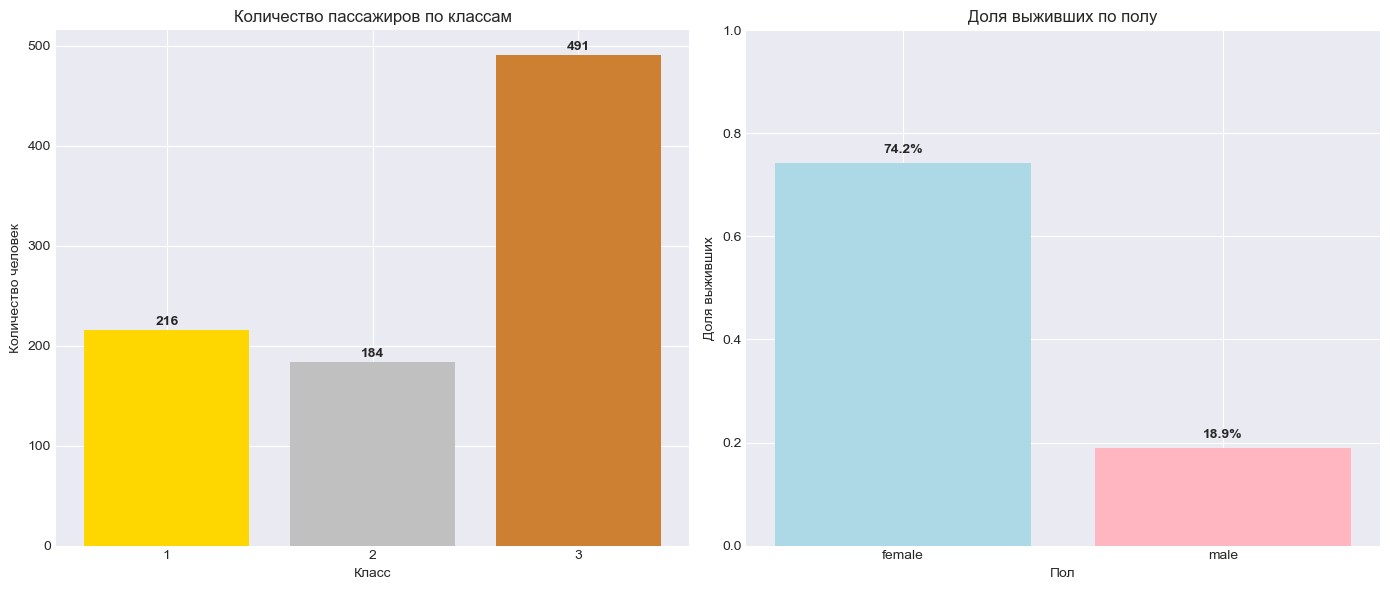

In [41]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_counts = df['Pclass'].value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=['gold', 'silver', '#cd7f32'])
axes[0].set_title('Количество пассажиров по классам')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество человек')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
    survival_by_sex = df.groupby('Sex')['Survived'].mean()
axes[1].bar(survival_by_sex.index, survival_by_sex.values, color=['lightblue', 'lightpink'])
axes[1].set_title('Доля выживших по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Доля выживших')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Собственный вопрос к данным. Как наличие родственников на борту (сумма SibSp и Parch) влияет на вероятность выживания?

Создаем признак "Количество родственников"

In [42]:
df['Relatives'] = df['SibSp'] + df['Parch']

Анализируем выживаемость в зависимости от числа родственников

In [43]:
survival_by_relatives = df.groupby('Relatives')['Survived'].mean().reset_index()

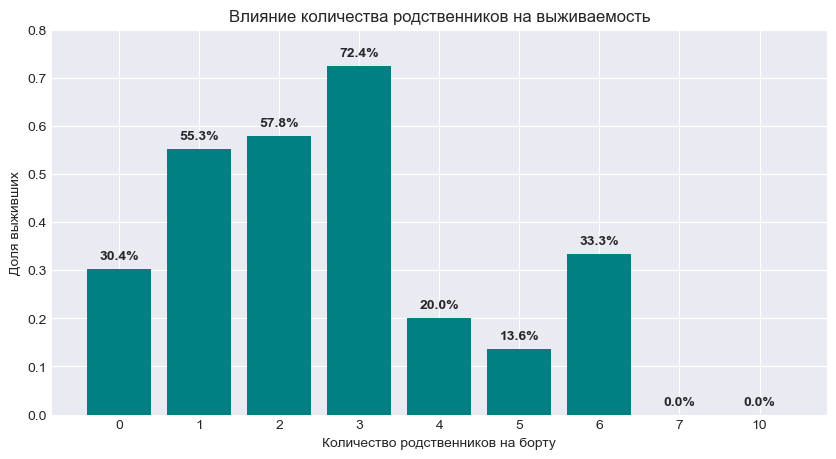

In [45]:
plt.figure(figsize=(10, 5))
plt.bar(survival_by_relatives['Relatives'].astype(str), survival_by_relatives['Survived'], color='teal')
plt.title('Влияние количества родственников на выживаемость')
plt.xlabel('Количество родственников на борту')
plt.ylabel('Доля выживших')
plt.ylim(0, 0.8)
for i, v in enumerate(survival_by_relatives['Survived']):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.show()

In [47]:
print("Статистика выживаемости по количеству родственников:", survival_by_relatives.round(3))

Статистика выживаемости по количеству родственников:    Relatives  Survived
0          0     0.304
1          1     0.553
2          2     0.578
3          3     0.724
4          4     0.200
5          5     0.136
6          6     0.333
7          7     0.000
8         10     0.000
